In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
fifa=pd.read_csv("../../data/fifa_world_cup_2026_player_performance.csv")
players=fifa.groupby(["player_name","team","position"],as_index=False).agg(Matches=("match_id","nunique"),Goals=("goals","sum"),Assists=("assists","sum"),Rating=("player_rating","mean"))
players=players.sort_values("Goals",ascending=False).head(10).reset_index(drop=True)
print("Dataset loaded successfully"); print("Shape:",players.shape); display(players)

Dataset loaded successfully
Shape: (10, 7)


,player_name,team,position,Matches,Goals,Assists,Rating
0,Memphis Zerrouki,Netherlands,Forward,54,24,9,4.607407
1,Kasey Hector,Jamaica,Forward,59,16,9,3.800000
2,Vinicius Nunes,Brazil,Forward,45,15,6,4.300000
3,Dominik Kramaric,Croatia,Forward,49,15,9,5.016327
4,Eric Rodriguez,Panama,Forward,47,15,5,4.776596
5,Mohannad Majeed,Iraq,Forward,41,15,10,4.270732
6,Randal Duarte,Costa Rica,Forward,46,14,6,4.273913
7,Eric Mba,Cameroon,Forward,44,14,7,5.379545
8,Gianluigi Calafiori,Italy,Forward,53,13,8,3.913208
9,Themba Xoki,South Africa,Forward,35,13,2,4.565714


In [2]:
print("Last records:"); display(players.tail())

Last records:


,player_name,team,position,Matches,Goals,Assists,Rating
5,Mohannad Majeed,Iraq,Forward,41,15,10,4.270732
6,Randal Duarte,Costa Rica,Forward,46,14,6,4.273913
7,Eric Mba,Cameroon,Forward,44,14,7,5.379545
8,Gianluigi Calafiori,Italy,Forward,53,13,8,3.913208
9,Themba Xoki,South Africa,Forward,35,13,2,4.565714


In [3]:
print("Data types:"); print(players.dtypes); print("\nStatistical summary:"); display(players.describe(include="all"))

Data types:
player_name     object
team            object
position        object
Matches          int64
Goals            int64
Assists          int64
Rating         float64
dtype: object

Statistical summary:


,player_name,team,position,Matches,Goals,Assists,Rating
count,10,10,10,10.00000,10.000000,10.000000,10.000000
unique,10,10,1,NaN,NaN,NaN,NaN
top,Memphis Zerrouki,Netherlands,Forward,NaN,NaN,NaN,NaN
freq,1,1,10,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,47.30000,15.400000,7.100000,4.490344
std,NaN,NaN,NaN,6.88073,3.169297,2.424413,0.484152
min,NaN,NaN,NaN,35.00000,13.000000,2.000000,3.800000
25%,NaN,NaN,NaN,44.25000,14.000000,6.000000,4.271527
50%,NaN,NaN,NaN,46.50000,15.000000,7.500000,4.432857
75%,NaN,NaN,NaN,52.00000,15.000000,9.000000,4.734299


In [4]:
filtered=players[(players["Rating"]>=7.5)&(players["Goals"]>=2)]; print("Players with rating 7.5 or above and at least 2 goals:"); display(filtered)

Players with rating 7.5 or above and at least 2 goals:


,player_name,team,position,Matches,Goals,Assists,Rating


In [5]:
print("Players sorted by rating:"); display(players.sort_values("Rating",ascending=False))

Players sorted by rating:


,player_name,team,position,Matches,Goals,Assists,Rating
7,Eric Mba,Cameroon,Forward,44,14,7,5.379545
3,Dominik Kramaric,Croatia,Forward,49,15,9,5.016327
4,Eric Rodriguez,Panama,Forward,47,15,5,4.776596
0,Memphis Zerrouki,Netherlands,Forward,54,24,9,4.607407
9,Themba Xoki,South Africa,Forward,35,13,2,4.565714
2,Vinicius Nunes,Brazil,Forward,45,15,6,4.300000
6,Randal Duarte,Costa Rica,Forward,46,14,6,4.273913
5,Mohannad Majeed,Iraq,Forward,41,15,10,4.270732
8,Gianluigi Calafiori,Italy,Forward,53,13,8,3.913208
1,Kasey Hector,Jamaica,Forward,59,16,9,3.800000


In [6]:
print("Position-wise statistical analysis:"); display(players.groupby("position")["Rating"].agg(["mean","median","min","max","std"]).round(2))

Position-wise statistical analysis:


,mean,median,min,max,std
position,,,,,
Forward,4.49,4.43,3.8,5.38,0.48


In [7]:
print("Correlation matrix:"); display(players[["Matches","Goals","Assists","Rating"]].corr().round(2))

Correlation matrix:


,Matches,Goals,Assists,Rating
Matches,1.00,0.46,0.62,-0.38
Goals,0.46,1.00,0.41,0.05
Assists,0.62,0.41,1.00,-0.18
Rating,-0.38,0.05,-0.18,1.00


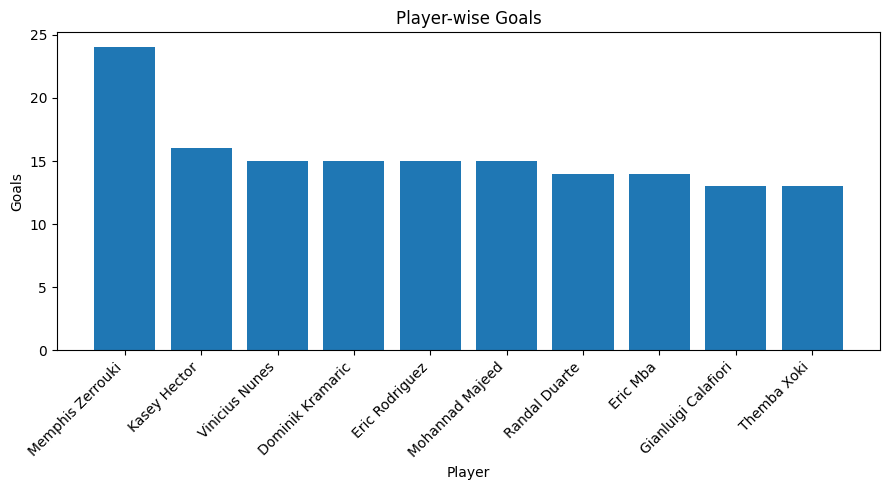

In [8]:
plt.figure(figsize=(9,5)); plt.bar(players["player_name"],players["Goals"]); plt.title("Player-wise Goals"); plt.xlabel("Player"); plt.ylabel("Goals"); plt.xticks(rotation=45,ha="right"); plt.tight_layout(); plt.show()

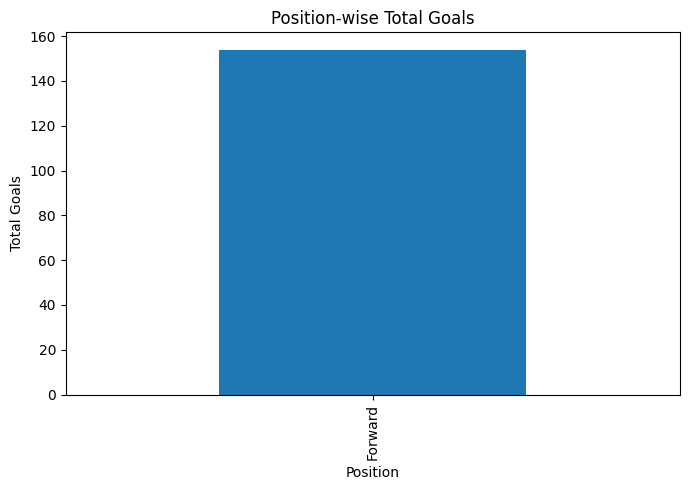

In [9]:
plt.figure(figsize=(7,5)); players.groupby("position")["Goals"].sum().plot(kind="bar"); plt.title("Position-wise Total Goals"); plt.xlabel("Position"); plt.ylabel("Total Goals"); plt.tight_layout(); plt.show()